Figure S12: Properties of pcQTLs and eQTLs. A In each tissue, the distribution of median expression of all genes in a cluster that had a significant pcQTL, the distribution of median expression of all genes in a cluster that had a significant eQTL, and the distribution of median expression of  eGenes from clusters that had a significant eQTL. P-values from two-sided Mann-Whitney U test. B Minor allele frequencies of lead variants for QTL credible sets discovered as pcQTLs or eQTLs are not significantly different (p=0.164). Minor allele frequencies for novel pcQTL lead variants are lower than eQTL lead variants (p=1.9*10-4), and all pcQTL lead variants (p=1.3*10-6). P-values from Mann-Whitney U test. C  For each lead variant for a QTL credible set, the fraction that falls within an ABC “genic” or “intergenic” regulatory element. eQTL is all eQTL credible set lead variants, pcQTL is all pcQTL credible set lead variants, novel pcQTL is lead variants from pcQTL credible sets that did not colocalize with any eQTL credible sets. 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from tqdm.auto import tqdm 
from scipy.stats import mannwhitneyu
import matplotlib.patches as mpatches
from tqdm.auto import tqdm
from statannotations.Annotator import Annotator


tqdm.pandas()

# get outputs from a config file
import yaml
config_path= '/home/klawren/oak/pcqtls/config_old/main_pcqtl.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

import sys
sys.path.append('/home/klawren/oak/pcqtls/workflow/scripts')
from utils import *


%config InlineBackend.figure_formats = ['png']
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
plt.rcParams.update({'font.size': 7})

# Define colors for eQTL vs pcQTL
qtl_colors = {'eqtl': '#6FA287', 'pcqtl_only': '#620059', 'pcqtl': '#9B4A8A'}

In [14]:
# Load SuSiE credible sets for eQTLs and pcQTLs
print("Loading SuSiE credible sets...")
eqtl_susie = load_across_tissues(config, load_e_susie)
eqtl_susie['cluster_id'] = eqtl_susie['phenotype_id'].str.split('_e_').str[0]
eqtl_susie['gene_id'] = eqtl_susie['cluster_id'].str.split('_')
eqtl_susie['egene_id'] = eqtl_susie['phenotype_id'].str.split('_e_').str[1]

pcqtl_susie = load_across_tissues(config, load_pc_susie)
pcqtl_susie['cluster_id'] = pcqtl_susie['phenotype_id'].str.split('_pc').str[0]
pcqtl_susie['gene_id'] = pcqtl_susie['cluster_id'].str.split('_')

Loading SuSiE credible sets...


In [15]:
pcgenes_all = pcqtl_susie.explode('gene_id')[['tissue_id', 'gene_id']].drop_duplicates()
egenes_all = eqtl_susie.explode('gene_id')[['tissue_id', 'gene_id']].drop_duplicates()
egenes_matched = eqtl_susie[['tissue_id', 'egene_id']].drop_duplicates()

print(f"{len(pcgenes_all)} pcQTL genes")
print(f"{len(egenes_all)} eQTL genes")
print(f"{len(egenes_matched)} eQTL matched genes")

# load expression data
median_expression = pd.read_table('/home/klawren/oak/pcqtls/data/references/GTEx_Analysis_2017-06-05_v8_RNASeQCv1.1.9_gene_median_tpm.gct.gz', comment='#', header=1, index_col=0).T.reset_index()
median_expression['tissue_id'] = median_expression['index'].str.replace(' - ', '_').str.replace(' ', '_').str.replace(')', '').str.replace('(', '')

# filter to tissues and genes considered
median_expression = median_expression[median_expression['tissue_id'].isin(load_tissue_ids(config))]
all_genes = pd.concat([pcgenes_all['gene_id'], egenes_all['gene_id']]).unique()
median_expression = median_expression[[*all_genes, 'tissue_id']]

# melt to long format
median_expr_long = median_expression.melt(id_vars='tissue_id', var_name='gene_id', value_name='median_expression')

pcgenes_all_expression = pd.merge(pcgenes_all, median_expr_long, on=['gene_id', 'tissue_id'], how='left')
egenes_all_expression = pd.merge(egenes_all, median_expr_long, on=['gene_id', 'tissue_id'], how='left')
egenes_matched_expression = pd.merge(egenes_matched, median_expr_long, left_on=['egene_id', 'tissue_id'], right_on=['gene_id', 'tissue_id'], how='left')

combined_df = pd.concat([pcgenes_all_expression, egenes_all_expression, egenes_matched_expression], keys=['pcQTL', 'eQTL', 'eQTL_matched']).reset_index(level=0).rename(columns={'level_0': 'qtl_type'}).reset_index(drop=True)
combined_df['log_expression'] = np.log10(combined_df['median_expression'].astype(float) + 1)

17592 pcQTL genes
17899 eQTL genes
13843 eQTL matched genes


In [ ]:
af_annot_qtls = load_across_tissues(config, load_susie_annotated)

lead_variants = af_annot_qtls.loc[af_annot_qtls.groupby(['phenotype_id', 'cs_id', 'tissue_id'])['pip'].idxmax()].copy()
lead_variants = lead_variants[~lead_variants['af'].isna()]
lead_variants['maf'] = np.where(lead_variants['af'] > 0.5, 1 - lead_variants['af'], lead_variants['af'])

In [88]:
print("Loading ABC data...")
abc_df = pd.read_table(f'{config["working_dir"]}/{config["abc_path"]}')
abc_df['num_connected_genes'] = abc_df.groupby('name')['TargetGene'].transform('nunique')
print(f"Loaded {len(abc_df)} ABC elements")
#abc_df = abc_df[abc_df['class'].isin(['intergenic'])]
print(f"Loaded {len(abc_df)} ABC distal elements")

Loading ABC data...
Loaded 7716121 ABC elements
Loaded 7716121 ABC distal elements


In [90]:
def annotate_in_abc_by_class(lead_variants, abc_df, tqdm=tqdm):
    """
    For each ABC 'class', annotate lead_variants with in_abc_{class}: True/False if lead variant overlaps an ABC element of that class.
    Modifies lead_variants in-place.
    """
    abc_classes = abc_df['class'].unique()
    abc_by_chr_class = {cls: abc_df[abc_df['class'] == cls].groupby('chr') for cls in abc_classes}

    for abc_class in abc_classes:
        col_name = f'in_abc_{abc_class}'
        lead_variants[col_name] = False
        abc_by_chr = abc_by_chr_class[abc_class]
        for chr_idx in tqdm(lead_variants['chr'].unique(), desc=f'Processing chromosomes [{abc_class}]'):
            chr_name = 'chr' + str(chr_idx)
            if chr_name not in abc_by_chr.groups:
                continue
            chr_abc = abc_by_chr.get_group(chr_name)[['start', 'end']].sort_values('start').values
            if len(chr_abc) == 0:
                continue
            # Merge overlapping intervals
            merged = []
            start, end = chr_abc[0]
            for s, e in chr_abc[1:]:
                if s <= end:
                    end = max(end, e)
                else:
                    merged.append((start, end))
                    start, end = s, e
            merged.append((start, end))

            # Create interval index
            intervals = pd.IntervalIndex.from_tuples(merged, closed='both')

            # Check QTL positions
            chr_mask = lead_variants['chr'] == chr_idx
            overlaps = intervals.get_indexer(lead_variants.loc[chr_mask, 'position'])
            lead_variants.loc[chr_mask, col_name] = overlaps >= 0

# Call the function to annotate in_abc_{class} columns
annotate_in_abc_by_class(lead_variants, abc_df)

Processing chromosomes [genic]:   0%|          | 0/22 [00:00<?, ?it/s]

Processing chromosomes [promoter]:   0%|          | 0/22 [00:00<?, ?it/s]

Processing chromosomes [intergenic]:   0%|          | 0/22 [00:00<?, ?it/s]

In [102]:
# which are from pcqtl only groups?
qtl_signal_groups = load_across_tissues(config, load_qtl_signal_groups)
qtl_signal_groups['qtl_cs_id'] = qtl_signal_groups['signal_id'].str.split('-')
qtl_signals_groups_exploded = qtl_signal_groups.explode('qtl_cs_id')
pcqtl_only_signal_groups = qtl_signals_groups_exploded[qtl_signals_groups_exploded['num_e_coloc'] == 0]

# variants found as pcqtls but not eqtls
lead_variants['qtl_cs_id'] = lead_variants['cs_id']
pcqtl_only_leads_af = lead_variants[lead_variants['qtl_cs_id'].isin(pcqtl_only_signal_groups['qtl_cs_id'])]

# combine into one dataframe
combined_lead_vars = pd.concat([lead_variants[lead_variants['type'] == 'pcqtl'][['maf', 'in_abc_promoter', 'in_abc_genic', 'in_abc_intergenic', 'tissue_id']], 
    lead_variants[lead_variants['type'] == 'eqtl'][['maf', 'in_abc_promoter', 'in_abc_genic', 'in_abc_intergenic', 'tissue_id']], 
    pcqtl_only_leads_af[['maf', 'in_abc_promoter', 'in_abc_genic', 'in_abc_intergenic', 'tissue_id']]], 
    keys=['pcqtl', 'eqtl', 'pcqtl_only']).reset_index(level=0).rename(columns={'level_0': 'qtl_type'})

combined_lead_vars['in_abc'] = combined_lead_vars[['in_abc_genic', 'in_abc_intergenic']].any(axis=1)

abc_fraction = combined_lead_vars.groupby(['tissue_id', 'qtl_type'])[['in_abc']].mean().reset_index()

/local/scratch/klawren/slrmtmp.49269327/ipykernel_8746/4259978626.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/local/scratch/klawren/slrmtmp.49269327/ipykernel_8746/4259978626.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_a.set_xticklabels(['pcQTL\n(cluster genes)', 'eQTL\n(cluster genes)', 'eQTL\n(eGenes)'])


expression
pcQTL vs. eQTL: Mann-Whitney-Wilcoxon test two-sided, P_val:4.324e-01 U_stat=1.582e+08
eQTL vs. eQTL_matched: Mann-Whitney-Wilcoxon test two-sided, P_val:5.861e-01 U_stat=1.233e+08
pcQTL vs. eQTL_matched: Mann-Whitney-Wilcoxon test two-sided, P_val:8.424e-01 U_stat=1.218e+08


/local/scratch/klawren/slrmtmp.49269327/ipykernel_8746/4259978626.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/local/scratch/klawren/slrmtmp.49269327/ipykernel_8746/4259978626.py:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_c.set_xticklabels(['eQTL', 'pcQTL', 'novel pcQTL'])


abc
pcqtl vs. eqtl: Mann-Whitney-Wilcoxon test two-sided, P_val:4.418e-01 U_stat=6.900e+01
eqtl vs. pcqtl_only: Mann-Whitney-Wilcoxon test two-sided, P_val:8.581e-04 U_stat=1.500e+02
pcqtl vs. pcqtl_only: Mann-Whitney-Wilcoxon test two-sided, P_val:4.025e-04 U_stat=1.540e+02


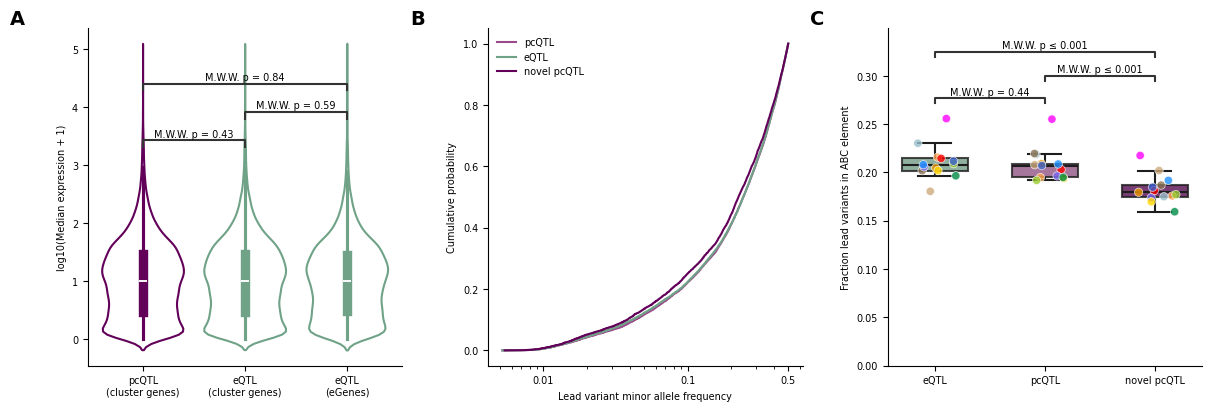

In [129]:

fig, axes = plt.subplots(1, 3, figsize=(12, 4), gridspec_kw={'width_ratios': [1, 1, 1]}, constrained_layout=True)
ax_a, ax_b, ax_c = axes

# Panel A: Violin plot for median expression
sns.violinplot(
    data=combined_df,
    x='qtl_type',
    y='log_expression',
    fill=False,
    legend=False,
    hue_order=['pcQTL', 'eQTL', 'eQTL_matched'],
    palette=[qtl_palette['pcQTL only'], qtl_palette['eQTL only'], qtl_palette['eQTL only']],
    ax=ax_a
)
ax_a.set_ylabel('log10(Median expression + 1)')
ax_a.set_xticklabels(['pcQTL\n(cluster genes)', 'eQTL\n(cluster genes)', 'eQTL\n(eGenes)'])
ax_a.set_xlabel('')
ax_a.spines[['top', 'right']].set_visible(False)

pairs = [
    ("pcQTL", "eQTL"),
    ("pcQTL", "eQTL_matched"),
    ("eQTL", "eQTL_matched"),
]
print("expression")
annotator = Annotator(ax_a, pairs, data=combined_df, x='qtl_type', y='log_expression', order=['pcQTL', 'eQTL', 'eQTL_matched'])
annotator.configure(test='Mann-Whitney', text_format='simple', loc='inside')
annotator.apply_and_annotate()

ax_a.text(-.2, 1, 'A', transform=ax_a.transAxes, fontsize=14, fontweight='bold', 
          ha='right', va='bottom')

# Panel B: CDF allele frequencies
for qtl_type in combined_lead_vars['qtl_type'].unique():
    data = combined_lead_vars[combined_lead_vars['qtl_type'] == qtl_type]['maf'].dropna()
    data_sorted = np.sort(data)
    cdf = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
    ax_b.plot(data_sorted, cdf, label=qtl_type, color=qtl_colors.get(qtl_type, '#888888'), linewidth=1.5)

ax_b.set_ylabel('Cumulative probability')
ax_b.set_xlabel('Lead variant minor allele frequency')
ax_b.spines[['top', 'right']].set_visible(False)
ax_b.legend(['pcQTL', 'eQTL', 'novel pcQTL'], frameon=False)
ax_b.set_xscale('log')
ax_b.set_xticks([.01, .1, .5])
ax_b.set_xticklabels(['0.01', '0.1', '0.5'])

ax_b.text(-.2, 1, 'B', transform=ax_b.transAxes, fontsize=14, fontweight='bold', 
          ha='right', va='bottom')

# Panel C: Fraction lead variants in ABC enhancers (box/stripplot as in cell 2)
# Set up the panel C plot, no need to create a new figure
sns.boxplot(
    data=abc_fraction, 
    x='qtl_type', 
    y='in_abc',
    palette=qtl_colors, 
    showfliers=False,
    width=0.6,
    linewidth=1.5,
    boxprops=dict(alpha=0.8),
    flierprops=dict(marker='o', markerfacecolor='white', markersize=4),
    ax=ax_c
)
sns.stripplot(
    data=abc_fraction, 
    x='qtl_type', 
    y='in_abc', 
    hue='tissue_id', 
    palette=gtex_tissue_dict, 
    size=6, 
    alpha=0.8, 
    jitter=0.2,
    linewidth=0.5,
    edgecolor='white',
    ax=ax_c, 
    legend=False
)
ax_c.set_ylabel('Fraction lead variants in ABC element')
ax_c.grid(False)
ax_c.set_ylim(0, ax_c.get_ylim()[1])
ax_c.set_xticklabels(['eQTL', 'pcQTL', 'novel pcQTL'])
ax_c.set_xlabel('')
sns.despine(ax=ax_c, top=True, right=True)
print("abc")
abc_pairs = [
    ("pcqtl", "eqtl"),
    ("pcqtl", "pcqtl_only"),
    ("eqtl", "pcqtl_only"),
]
abc_order = ['pcqtl', 'eqtl', 'pcqtl_only']
annotator_c = Annotator(ax_c, abc_pairs, data=abc_fraction, x='qtl_type', y='in_abc', order=abc_order)
annotator_c.configure(test='Mann-Whitney', text_format='simple', loc='inside')
annotator_c.apply_and_annotate()

ax_c.text(-.2, 1, 'C', transform=ax_c.transAxes, fontsize=14, fontweight='bold', 
          ha='right', va='bottom')

plt.show()

In [119]:
stat1, p1 = mannwhitneyu(combined_lead_vars[combined_lead_vars['qtl_type'] == 'pcqtl']['maf'].dropna(), 
                         combined_lead_vars[combined_lead_vars['qtl_type'] == 'eqtl']['maf'].dropna(), 
                         alternative='two-sided')
print(f"eQTL vs pcQTL:")
print(f"  Mann-Whitney U test p-value: {p1:.2e}")
print(f"  Significant difference: {'Yes' if p1 < 0.05 else 'No'}")

stat2, p2 = mannwhitneyu(combined_lead_vars[combined_lead_vars['qtl_type'] == 'pcqtl']['maf'].dropna(), 
                         combined_lead_vars[combined_lead_vars['qtl_type'] == 'pcqtl_only']['maf'].dropna(), 
                         alternative='two-sided')
print(f"pcQTL vs pcQTL only:")
print(f"  Mann-Whitney U test p-value: {p2:.2e}")
print(f"  Significant difference: {'Yes' if p2 < 0.05 else 'No'}")

stat3, p3 = mannwhitneyu(combined_lead_vars[combined_lead_vars['qtl_type'] == 'pcqtl_only']['maf'].dropna(), 
                         combined_lead_vars[combined_lead_vars['qtl_type'] == 'eqtl']['maf'].dropna(), 
                         alternative='two-sided')
print(f"pcQTL only vs eQTL:")
print(f"  Mann-Whitney U test p-value: {p3:.2e}")
print(f"  Significant difference: {'Yes' if p3 < 0.05 else 'No'}")

eQTL vs pcQTL:
  Mann-Whitney U test p-value: 4.73e-01
  Significant difference: No
pcQTL vs pcQTL only:
  Mann-Whitney U test p-value: 5.89e-08
  Significant difference: Yes
pcQTL only vs eQTL:
  Mann-Whitney U test p-value: 1.01e-06
  Significant difference: Yes
